# Demo Notebook: Transfer Learning for Vision

This demo uses a **real image task** where transfer learning is easy to justify: distinguishing **cats** from **dogs** using a small subset of CIFAR-10.

The notebook compares two routes:

- a conventional baseline using **raw pixels + logistic regression**;
- a transfer-learning route using **pretrained ResNet18 features + logistic regression**.

This is a stronger teaching demo than a toy synthetic example because the representation problem is obvious: raw pixels are hard to model directly, while a pretrained vision encoder already captures useful visual patterns.

## What this demo is for

Use this notebook to show that transfer learning is not magic. It works because the pretrained model has already learned reusable visual features such as edges, textures, and shapes.

For workshop pacing, keep the subset small so the feature extraction step finishes quickly on a laptop.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

CLASS_IDS = [3, 5]  # CIFAR-10: cat, dog
CLASS_NAMES = {3: 'cat', 5: 'dog'}
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 200

Using device: cpu


In [3]:
base_train = datasets.CIFAR10(root='data', train=True, download=True)
base_test = datasets.CIFAR10(root='data', train=False, download=True)

def select_indices(targets, class_ids, max_per_class):
    counts = {class_id: 0 for class_id in class_ids}
    selected = []
    for idx, label in enumerate(targets):
        if label in counts and counts[label] < max_per_class:
            selected.append(idx)
            counts[label] += 1
        if all(count == max_per_class for count in counts.values()):
            break
    return selected

train_idx = select_indices(base_train.targets, CLASS_IDS, TRAIN_PER_CLASS)
test_idx = select_indices(base_test.targets, CLASS_IDS, TEST_PER_CLASS)

print('Training images:', len(train_idx))
print('Test images:', len(test_idx))

100%|██████████| 170M/170M [00:09<00:00, 17.1MB/s] 
/opt/anaconda3/envs/aaib26/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training images: 1000
Test images: 400


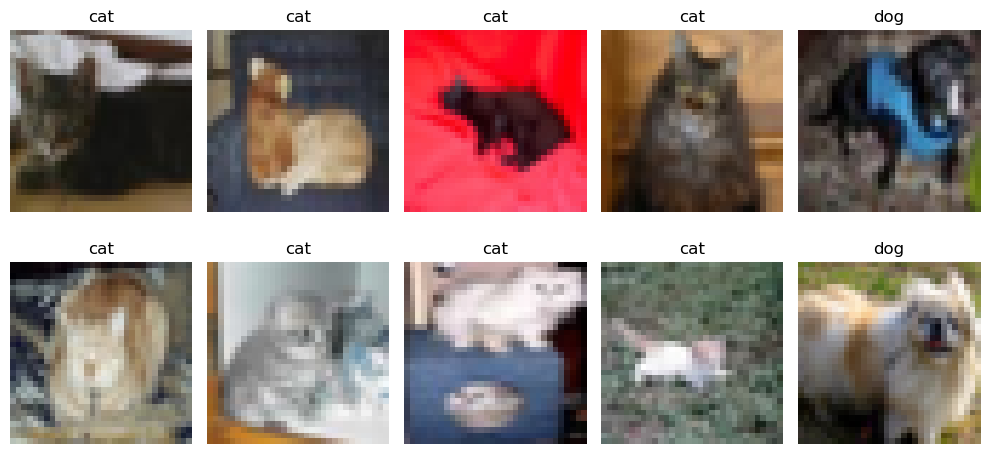

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), train_idx[:10]):
    image, label = base_train[idx]
    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Baseline 1: raw pixels + logistic regression

This baseline is intentionally simple. It treats each pixel as just another input feature and ignores the richer spatial structure that CNNs are designed to use.

In [5]:
X_train_raw = np.stack([base_train.data[i].astype('float32').reshape(-1) / 255.0 for i in train_idx])
y_train = np.array([0 if base_train.targets[i] == CLASS_IDS[0] else 1 for i in train_idx])

X_test_raw = np.stack([base_test.data[i].astype('float32').reshape(-1) / 255.0 for i in test_idx])
y_test = np.array([0 if base_test.targets[i] == CLASS_IDS[0] else 1 for i in test_idx])

pixel_clf = LogisticRegression(max_iter=1000)
pixel_clf.fit(X_train_raw, y_train)
pixel_preds = pixel_clf.predict(X_test_raw)

pixel_accuracy = accuracy_score(y_test, pixel_preds)
print('Raw-pixel baseline accuracy:', round(pixel_accuracy, 3))

Raw-pixel baseline accuracy: 0.522


## Transfer-learning route: pretrained ResNet18 features

Here we keep the pretrained encoder frozen and only learn a simple classifier on top of the extracted features. This is often the safest workshop-scale transfer-learning pattern.

In [6]:
weights = models.ResNet18_Weights.DEFAULT
preprocess = weights.transforms()

class FilteredCIFAR10(Dataset):
    def __init__(self, base_dataset, indices, preprocess, class_ids):
        self.base_dataset = base_dataset
        self.indices = indices
        self.preprocess = preprocess
        self.class_ids = class_ids

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        image = self.preprocess(image)
        label = 0 if label == self.class_ids[0] else 1
        return image, label

train_dataset = FilteredCIFAR10(base_train, train_idx, preprocess, CLASS_IDS)
test_dataset = FilteredCIFAR10(base_test, test_idx, preprocess, CLASS_IDS)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
resnet = models.resnet18(weights=weights).to(device)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
feature_extractor.eval()

def extract_features(loader, model, device):
    features = []
    labels = []
    with torch.no_grad():
        for images, batch_labels in loader:
            outputs = model(images.to(device))
            outputs = outputs.squeeze(-1).squeeze(-1).cpu().numpy()
            features.append(outputs)
            labels.append(batch_labels.numpy())
    return np.vstack(features), np.concatenate(labels)

X_train_embed, y_train_embed = extract_features(train_loader, feature_extractor, device)
X_test_embed, y_test_embed = extract_features(test_loader, feature_extractor, device)

print('Embedding table shape:', X_train_embed.shape)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/cul/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 18.0MB/s]


Embedding table shape: (1000, 512)


In [8]:
embed_clf = LogisticRegression(max_iter=1000)
embed_clf.fit(X_train_embed, y_train_embed)
embed_preds = embed_clf.predict(X_test_embed)

embed_accuracy = accuracy_score(y_test_embed, embed_preds)
print('Pretrained-feature accuracy:', round(embed_accuracy, 3))

results = pd.DataFrame({
    'model': ['Raw pixels + logistic regression', 'Pretrained ResNet18 features + logistic regression'],
    'accuracy': [pixel_accuracy, embed_accuracy]
})
display(results)

Pretrained-feature accuracy: 0.828


,model,accuracy
0,Raw pixels + logistic regression,0.5225
1,Pretrained ResNet18 features + logistic regres...,0.8275


Classification report for pretrained features:
              precision    recall  f1-score   support

         cat       0.82      0.84      0.83       200
         dog       0.84      0.81      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



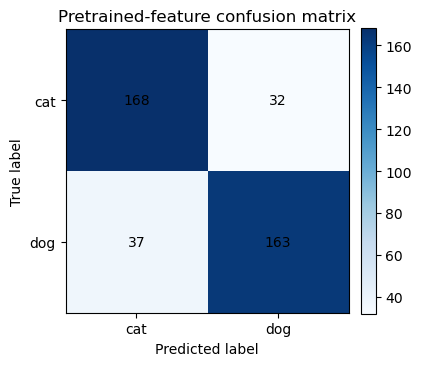

In [9]:
print('Classification report for pretrained features:')
print(classification_report(y_test_embed, embed_preds, target_names=['cat', 'dog']))

cm = confusion_matrix(y_test_embed, embed_preds)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['cat', 'dog'])
ax.set_yticklabels(['cat', 'dog'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Pretrained-feature confusion matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Interpretation

Use this result to discuss:

- why pretrained visual features can help when raw pixels are a poor representation;
- why transfer learning is often more realistic than training a CNN from scratch in a short workshop;
- why you should still compare against a sensible baseline rather than assuming the pretrained route must win.